# Chapter 3: Two-Asset Portfolio and Diversification

This notebook demonstrates portfolio mathematics for two risky assets using real market data.

In [1]:
import sys
sys.path.append('../')

import numpy as np
import matplotlib.pyplot as plt

from src.chapter2_returns import simple_return, expected_return, volatility
from src.chapter3_portfolio import portfolio_return, portfolio_variance, covariance_matrix
from src.data_utils import download_and_save_prices, load_prices_from_csv

## Download Asset Data

We use UBS and Nestlé as two risky assets to build a two-asset portfolio.

In [2]:
start_date = '2022-01-01'
end_date = '2024-01-01'

prices_ubs, _ = download_and_save_prices('UBS', start_date, end_date, data_dir='../data')
prices_nesn, _ = download_and_save_prices('NESN.SW', start_date, end_date, data_dir='../data')

# Align lengths in case of mismatched trading days
min_len = min(len(prices_ubs), len(prices_nesn))
prices_ubs = prices_ubs[:min_len]
prices_nesn = prices_nesn[:min_len]

print(f"Number of trading days: {min_len}")

✓ Saved to ../data/UBS_2022-01-01_2024-01-01.csv
✓ Saved to ../data/NESN.SW_2022-01-01_2024-01-01.csv
Number of trading days: 501


## Individual Asset Metrics

In [3]:
ret_ubs = simple_return(prices_ubs)
ret_nesn = simple_return(prices_nesn)

mu_ubs = expected_return(ret_ubs) * 252
mu_nesn = expected_return(ret_nesn) * 252

vol_ubs = volatility(ret_ubs) * np.sqrt(252)
vol_nesn = volatility(ret_nesn) * np.sqrt(252)

print(f"{'Asset':<10} {'E[r] (annual)':>15} {'Vol (annual)':>14}")
print("-" * 42)
print(f"{'UBS':<10} {mu_ubs*100:>14.2f}% {vol_ubs*100:>13.2f}%")
print(f"{'Nestlé':<10} {mu_nesn*100:>14.2f}% {vol_nesn*100:>13.2f}%")

Asset        E[r] (annual)   Vol (annual)
------------------------------------------
UBS                 35.77%         35.20%
Nestlé             -10.64%         16.59%


## Covariance Matrix and Correlation

The covariance matrix $\Sigma$ captures how assets move together:

$$\Sigma = \begin{pmatrix} \sigma_1^2 & \sigma_{12} \\ \sigma_{12} & \sigma_2^2 \end{pmatrix}$$

In [4]:
returns_matrix = np.array([ret_ubs, ret_nesn])
cov_mat = covariance_matrix(returns_matrix)

# Annualize covariance matrix
cov_mat_annual = cov_mat * 252

correlation = cov_mat[0, 1] / (np.std(ret_ubs, ddof=1) * np.std(ret_nesn, ddof=1))

print(f"Annualized Covariance Matrix:")
print(f"  UBS-UBS:    {cov_mat_annual[0,0]:.6f}")
print(f"  UBS-NESN:   {cov_mat_annual[0,1]:.6f}")
print(f"  NESN-NESN:  {cov_mat_annual[1,1]:.6f}")
print(f"\nCorrelation (UBS, Nestlé): {correlation:.4f}")

Annualized Covariance Matrix:
  UBS-UBS:    0.123890
  UBS-NESN:   -0.000800
  NESN-NESN:  0.027535

Correlation (UBS, Nestlé): -0.0137


## Portfolio Construction

For a portfolio with weights $w_1$ in UBS and $w_2 = 1 - w_1$ in Nestlé:

$$E[r_p] = w_1 \mu_1 + w_2 \mu_2$$

$$\sigma_p^2 = w^\top \Sigma w$$

In [5]:
# Equal-weight portfolio
weights = np.array([0.5, 0.5])
mu_assets = np.array([mu_ubs, mu_nesn])

port_ret = portfolio_return(weights, mu_assets)
port_var = portfolio_variance(weights, cov_mat_annual)
port_vol = np.sqrt(port_var)

print(f"Equal-weight portfolio (50% UBS / 50% Nestlé):")
print(f"  Expected return: {port_ret*100:.2f}%")
print(f"  Variance:        {port_var:.6f}")
print(f"  Volatility:      {port_vol*100:.2f}%")
print(f"\nDiversification benefit:")
print(f"  Weighted avg volatility: {(0.5*vol_ubs + 0.5*vol_nesn)*100:.2f}%")
print(f"  Portfolio volatility:    {port_vol*100:.2f}%")
print(f"  Risk reduction:          {((0.5*vol_ubs + 0.5*vol_nesn) - port_vol)*100:.2f}%")

Equal-weight portfolio (50% UBS / 50% Nestlé):
  Expected return: 12.57%
  Variance:        0.037456
  Volatility:      19.35%

Diversification benefit:
  Weighted avg volatility: 25.90%
  Portfolio volatility:    19.35%
  Risk reduction:          6.54%


## Efficient Frontier (Two Assets)

By varying $w_1$ from 0 to 1, we trace all possible risk-return combinations.

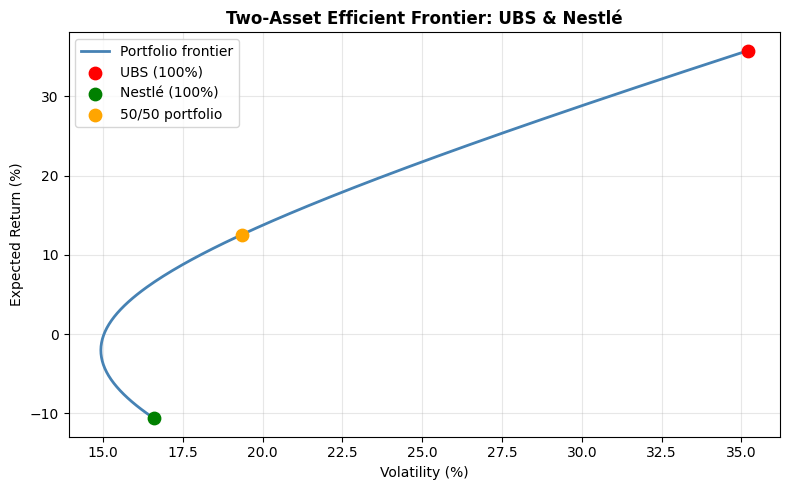

In [6]:
weight_range = np.linspace(0, 1, 200)
frontier_returns = []
frontier_vols = []

for w in weight_range:
    w_vec = np.array([w, 1 - w])
    frontier_returns.append(portfolio_return(w_vec, mu_assets))
    frontier_vols.append(np.sqrt(portfolio_variance(w_vec, cov_mat_annual)))

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(np.array(frontier_vols) * 100, np.array(frontier_returns) * 100,
        color='steelblue', linewidth=2, label='Portfolio frontier')

ax.scatter([vol_ubs * 100], [mu_ubs * 100], color='red', zorder=5, s=80, label='UBS (100%)')
ax.scatter([vol_nesn * 100], [mu_nesn * 100], color='green', zorder=5, s=80, label='Nestlé (100%)')
ax.scatter([port_vol * 100], [port_ret * 100], color='orange', zorder=5, s=80, label='50/50 portfolio')

ax.set_xlabel('Volatility (%)')
ax.set_ylabel('Expected Return (%)')
ax.set_title('Two-Asset Efficient Frontier: UBS & Nestlé', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated:

1. **Covariance matrix**: Captures co-movement between assets
2. **Portfolio return**: Weighted average of individual expected returns
3. **Portfolio variance**: Quadratic form $w^\top \Sigma w$ — accounts for correlation
4. **Diversification**: Combining assets with correlation < 1 reduces portfolio risk
5. **Efficient frontier**: The set of all risk-return combinations across portfolio weights